# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [3]:
# Crear carpeta si no existe
os.makedirs('datasets_raw', exist_ok=True)

# Guardar copia raw inmediatamente después de cargar
plans.to_csv('datasets_raw/plans_raw.csv', index=False)
users.to_csv('datasets_raw/users_raw.csv', index=False)
usage.to_csv('datasets_raw/usage_raw.csv', index=False)

# Verificación
archivos_raw = {
    'plans_raw.csv' : 'datasets_raw/plans_raw.csv',
    'users_raw.csv' : 'datasets_raw/users_raw.csv',
    'usage_raw.csv' : 'datasets_raw/usage_raw.csv'
}

print("📁 Verificación de archivos raw exportados:\n")
for nombre, ruta in archivos_raw.items():
    tamanio = os.path.getsize(ruta)
    estado  = "✅ OK" if tamanio > 0 else "❌ VACÍO"
    print(f"  {estado} — {nombre}: {tamanio:,} bytes")

📁 Verificación de archivos raw exportados:

  ✅ OK — plans_raw.csv: 185 bytes
  ✅ OK — users_raw.csv: 269,222 bytes
  ✅ OK — usage_raw.csv: 2,107,964 bytes


In [4]:
# mostrar las primeras 5 filas de plansplans.head()
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users

print("Conteo absoluto de nulos:\n", users.isna().sum())
print("\nProporción de nulos:\n", users.isna().mean())

Conteo absoluto de nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Conteo absoluto de nulos en usage:\n", usage.isna().sum())
print("\nProporción de nulos en usage:\n", usage.isna().mean())

Conteo absoluto de nulos en usage:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en usage:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
Contestando ambas prenguntas en esta ultima pregunta seria
-churn_date (~88.3% nulos): Es un comportamiento esperado, ya que la gran mayoría de los clientes sigue activa y no ha cancelado su plan. Acción: Ignorar/Mantener como nulos para el análisis general.

-duration (~55% nulos)

length (~45% nulos): Tienen una alta proporción de nulos, pero esto ocurre porque un evento o es llamada o es mensaje, nunca ambos. Acción: Conservar los nulos por ahora; en la etapa de agrupación los rellenaremos con 0.

-city (~11.7% nulos): Una proporción moderada de clientes sin ciudad registrada. Acción: Reemplazar por un nulo nativo de Pandas (pd.NA) o la etiqueta "Desconocido".

-date (~0.12% nulos): Proporción insignificante. Acción: Ignorar o eliminar, no afectarán las métricas globales.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` Contiene identificadores lógicos que van desde el 10000 hasta el 13999. No se aprecian métricas anómalas.
- La columna `age` Se observa un valor mínimo estadísticamente imposible (-999.0). Es claramente un valor sentinel (marcador de error o falta de captura) que distorsiona el promedio general.

In [14]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` Operan correctamente como llaves numéricas continuas sin anomalías aparentes.
- Las columnas numéricas de uso (duration y length): Sus mínimos en 0 tienen sentido operativo (llamadas perdidas o mensajes vacíos). Sin embargo, los máximos (ej. 120 minutos de llamada) sugieren la presencia de valores atípicos (Heavy Users) que evaluaremos en el análisis de outliers.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos y conteos para la columna: {col}")
    print(users[col].value_counts(dropna=False))
    print("-" * 40)

Valores únicos y conteos para la columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
----------------------------------------
Valores únicos y conteos para la columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
----------------------------------------


- La columna `city` Contiene un valor inválido explícito (?) en 96 registros, que actúa como sentinel para ubicaciones no registradas.
- La columna `plan` Datos limpios y estandarizados. Solo contiene las dos categorías comerciales esperadas ("Basico" y "Premium").

In [16]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` Datos totalmente consistentes, registrando únicamente los dos servicios válidos ("call" y "text").


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Encontré sentinels en la columna age (valor numérico -999) y en la columna city (carácter "?").

- ¿Qué acción tomarías?
Para la edad, la acción óptima es imputar con la mediana (excluyendo previamente el -999 del cálculo para no sesgarlo). Para la ciudad, lo reemplazaré por el marcador nulo oficial de Pandas (pd.NA) para estandarizar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, observamos 40 registros de clientes con año de registro en 2026. Dado que los datos llegan hasta 2024, esto representa fechas futuras imposibles o errores tipográficos en la base de datos.

In [20]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False))

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, todos los registros temporales pertenecen al año 2024, lo cual es perfectamente congruente, con solo 50 valores nulos que vimos anteriormente.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Sí, en la columna reg_date (usuarios) existen 40 registros con un año en el futuro (2026).

- ¿Qué harías con ellas?
Para mantener la integridad temporal sin borrar clientes, inyectaremos un nulo nativo de tiempo (pd.NaT) en esas fechas imposibles.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age

age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:

# Marcar fechas futuras como NaT (el nulo correcto para fechas) asumiendo límite año 2024
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios para ver cuántos registros quedaron como nulos (NaT)
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage['duration'].isna().groupby(usage['type']).mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
if 'length' in usage.columns:
    print(usage['length'].isna().groupby(usage['type']).mean())
else:
    print("La columna 'length' no está presente en este dataset de consumos.")

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

-Los nulos en las columnas de consumo están fuertemente condicionados: si el tipo (type) es mensaje ("text"), el 100% de la duración de llamada falta. Si el tipo es llamada ("call"), la longitud del mensaje falta. Por ende, confirmamos que son nulos tipo MAR (Missing At Random) dependientes del tipo de servicio.

Acción: Es correcto conservarlos como nulos en la tabla de transacciones, y posteriormente rellenarlos con 0 al momento de agrupar los totales por cliente, ya que representan una ausencia lógica de consumo y no un error en los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Los usuarios sin registros de consumo se rellenan con 0 en lugar de dejar nulos confusos
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,5.523000,4.477000,23.311225
std,1154.844867,17.689919,2.359738,2.145139,18.169564
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.107500
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.412500
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

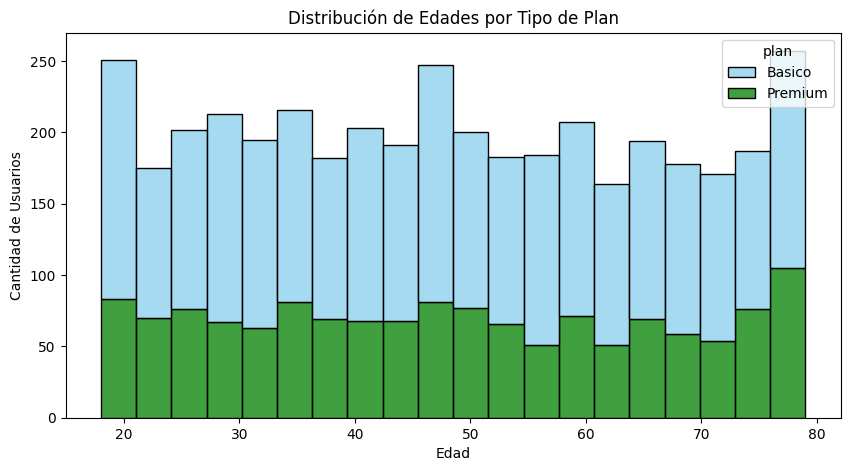

In [31]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], multiple='stack', bins=20)
plt.title('Distribución de Edades por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución de Edades: La distribución es amplia y relativamente uniforme a lo largo de todos los rangos (desde los 18 hasta casi 80 años). No se observa un pico generacional dominante, lo que indica que el servicio de ConnectaTel apela a todas las edades por igual. Además, la proporción de clientes con plan Básico y Premium se mantiene estable sin importar la edad del usuario.

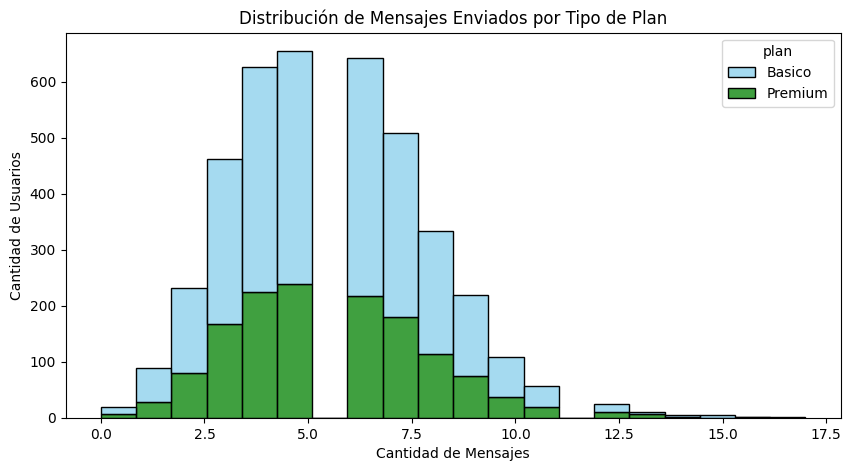

In [32]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], multiple='stack', bins=20)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución de Mensajes y Llamadas: La distribución presenta un fuerte sesgo hacia la derecha (right-skewed). La inmensa mayoría de la base de clientes envía menos de 6 mensajes en promedio, independientemente del plan contratado. Sin embargo, se observa una "larga cola" extendiéndose hacia la derecha, conformada por una minoría de usuarios que hacen un uso intensivo del servicio de mensajería (llegando a más de 15 mensajes).

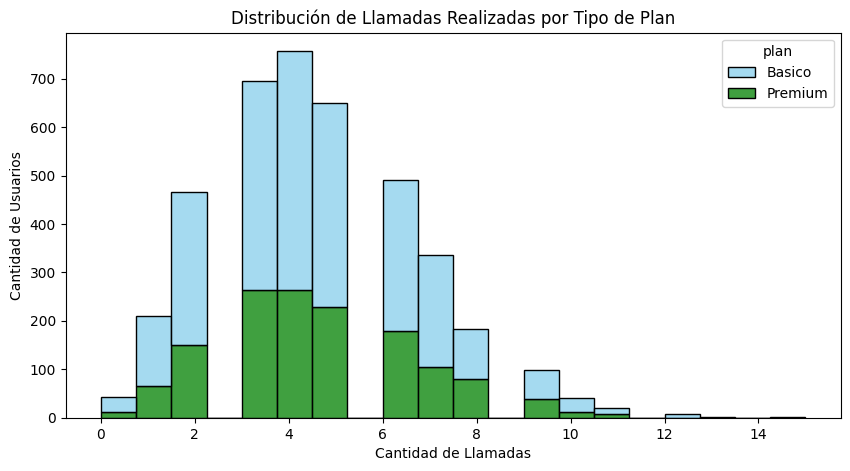

In [33]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], multiple='stack', bins=20)
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución al igual que los mensajes, la frecuencia de llamadas tiene un claro sesgo positivo. El comportamiento típico de los usuarios se concentra entre las 2 y 6 llamadas. Las barras a la derecha revelan la existencia de heavy users (usuarios frecuentes) que superan las 10 llamadas, un grupo clave para evaluar estrategias de fidelización y venta cruzada (upsell).

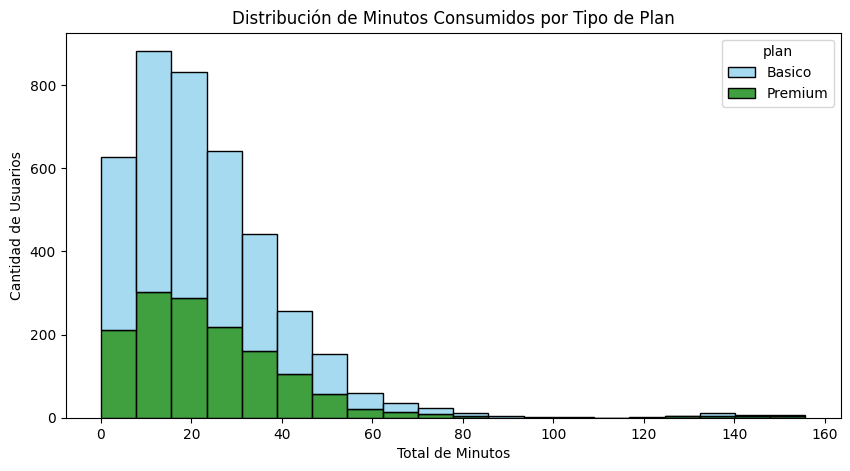

In [34]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], multiple='stack', bins=20)
plt.title('Distribución de Minutos Consumidos por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Esta es la variable con mayor dispersión visual. Aunque el grueso del volumen de usuarios (la moda) consume menos de 40 minutos de llamada, la larga cola evidencia a usuarios extremos que superan los 100 e incluso 150 minutos. Identificar si estos clientes de altísimo consumo están en un plan Básico o Premium es vital para evitar fugas (churn) por insatisfacción o cobros excesivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

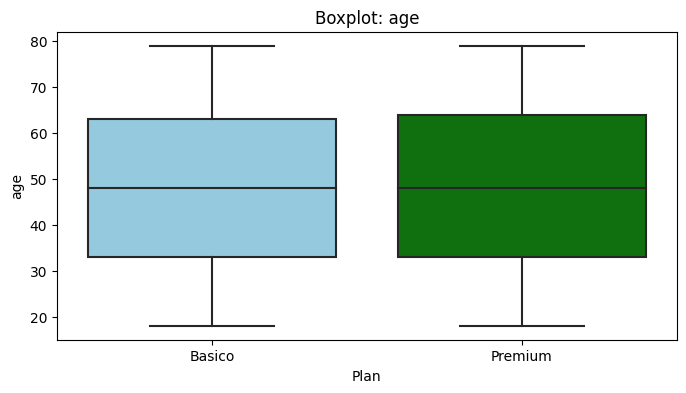

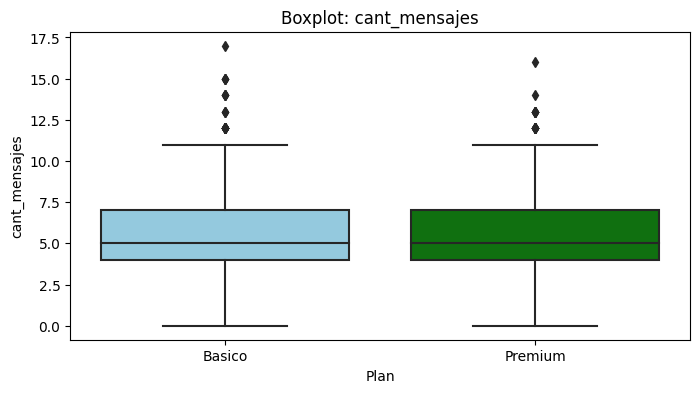

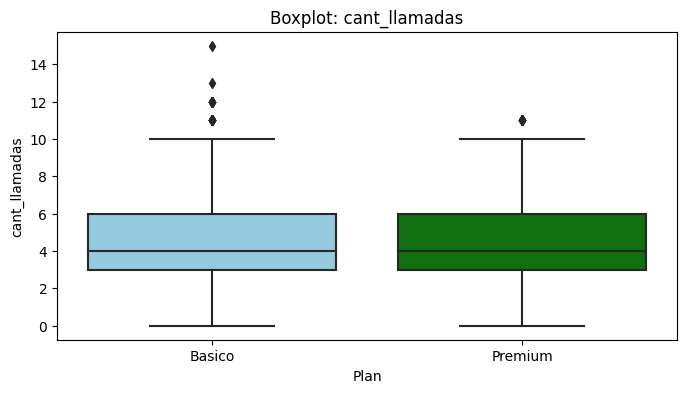

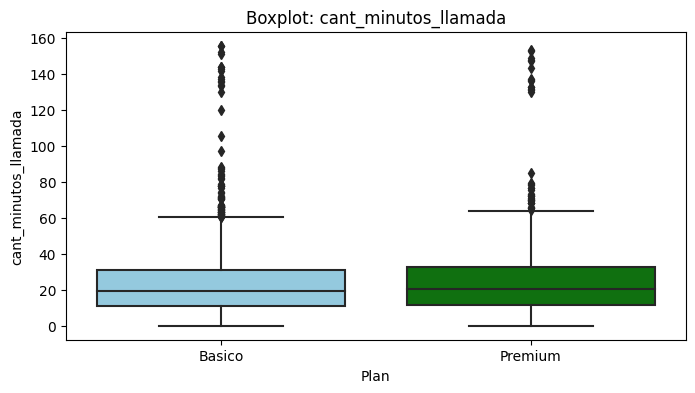

In [35]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x='plan', y=col, palette=['skyblue','green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()

💡Insights: 

Age: No presenta outliers. La caja y los bigotes cubren el comportamiento demográfico esperado de adultos.

cant_mensajes: Presenta múltiples outliers por encima del bigote superior (clientes extremadamente "texteadores").

cant_llamadas: Presenta outliers en el extremo superior.

cant_minutos_llamada: Presenta outliers muy lejanos en el extremo superior, denotando individuos con tiempos de llamada inusualmente prolongados.

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior estadístico para {col}: {limite_superior}")


Límite superior estadístico para cant_mensajes: 11.5
Límite superior estadístico para cant_llamadas: 10.5
Límite superior estadístico para cant_minutos_llamada: 61.870000000000005


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

cant_mensajes: Mantener. Estos valores superiores (ej. 17 mensajes) son un comportamiento de consumo válido (heavy users), eliminarlos ocultaría a nuestros mejores clientes.

- cant_llamadas: mantener o no outliers, porqué?

cant_llamadas: Mantener. Un cliente haciendo 15 llamadas diarias o mensuales es un evento real y es clave para evaluar si el plan Premium los está cubriendo.

- cant_minutos_llamada: mantener o no outliers, porqué?

cant_minutos_llamada: Mantener. La duración de más de 150 minutos representa eventos raros pero reales (como teletrabajo o llamadas internacionales largas). Conservarlos permite al negocio planificar paquetes "ilimitados".


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 
        'Uso medio', 
        'Alto uso'
    )
)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 
    'Joven',
    np.where(
        user_profile['age'] < 60, 
        'Adulto', 
        'Adulto Mayor'
    )
)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

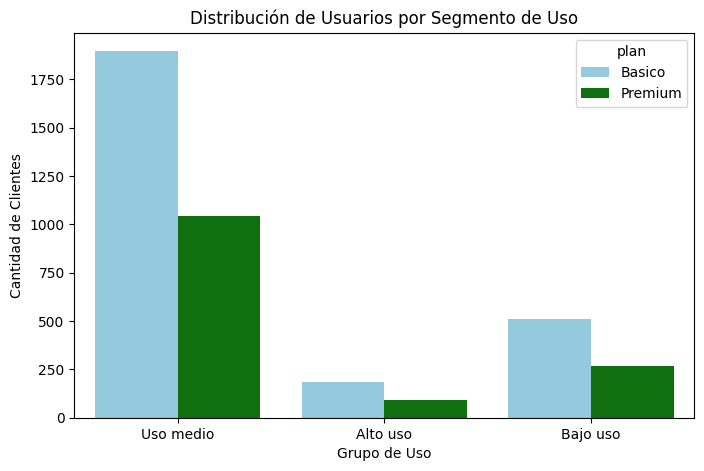

In [42]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Usuarios por Segmento de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

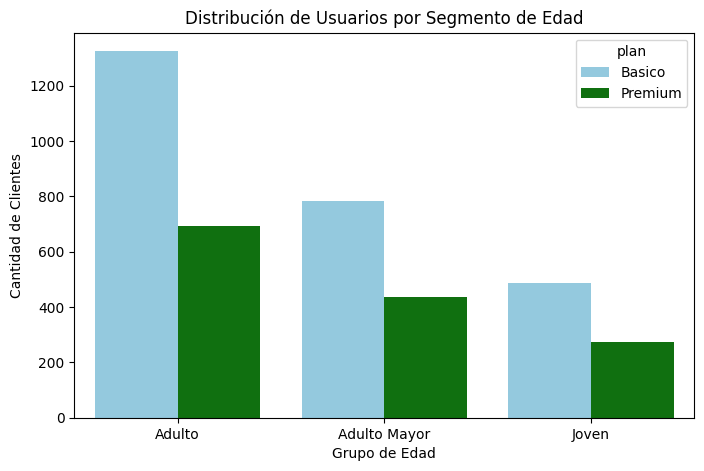

In [43]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [ ]:
# Crear carpeta si no existe
os.makedirs('datasets_clean', exist_ok=True)

# Guardar copias limpias
plans.to_csv('datasets_clean/plans_clean.csv', index=False)
users.to_csv('datasets_clean/users_clean.csv', index=False)
usage.to_csv('datasets_clean/usage_clean.csv', index=False)

# Verificar que los archivos no quedaron vacíos
archivos = {
    'plans_clean.csv' : 'datasets_clean/plans_clean.csv',
    'users_clean.csv' : 'datasets_clean/users_clean.csv',
    'usage_clean.csv' : 'datasets_clean/usage_clean.csv'
}

print("📁 Verificación de archivos exportados:\n")
for nombre, ruta in archivos.items():
    tamanio = os.path.getsize(ruta)
    estado  = "✅ OK" if tamanio > 0 else "❌ VACÍO"
    print(f"  {estado} — {nombre}: {tamanio:,} bytes")


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ Problemas detectados en los datos

    Presencia de Sentinels: Se encontraron edades registradas como -999 y ciudades marcadas con ?. Se requirió imputación (mediana para edad, pd.NA para textos) para evitar la distorsión del perfil promedio del cliente.

    Fallas cronológicas: 40 clientes figuraban con registro en 2026 (año futuro), requiriendo limpieza y homologación hacia NaT.

    Nulos estructurales (MAR): El 55% de la tabla usage estaba vacía en la duración y 45% en la longitud. Al descubrir que dependían lógicamente del tipo de transacción (texto vs. llamada), se abordaron consolidándolos con agrupaciones matemáticas limpias.

🔍 Segmentos por Edad

    ConnectaTel no depende de un único bloque generacional; el uso se distribuye equitativamente entre Jóvenes (<30), Adultos (<60) y Adultos Mayores.

    No hay una brecha abismal en la elección del plan (Básico vs Premium) dictada únicamente por la edad. El factor decisivo está en la intensidad del uso, no en el año de nacimiento.

📊 Segmentos por Nivel de Uso

    Asimetría de la Demanda: Las distribuciones muestran un claro sesgo positivo. El groso de la cartera hace uso conservador de sus servicios, pero existe una importante minoría (valores atípicos/Heavy Users) con picos severos de consumo en llamadas y mensajes.

    Validación de Outliers: Los datos extremos no son producto de fraude técnico, sino que retratan a perfiles altamente dependientes de la telecomunicación y usuarios clave para el ARPU (Ingreso Promedio por Usuario) de la empresa.


➡️ Esto sugiere que ...

El modelo actual agrupa en el "Plan Premium" a clientes con disparidades de consumo gigantescas. Mientras algunos subutilizan el plan, los "Heavy Users" ubicados en el segmento atípico saturan la métrica y podrían estar buscando mayor elasticidad en las bolsas de minutos.

💡 **Recomendaciones**

Migración Cruzada (Upsell): Lanzar campañas segmentadas hacia los clientes etiquetados como "Alto Uso" que actualmente se encuentran en el plan "Básico", invitándolos a subir a "Premium" mostrándoles la reducción en tarifas de excedentes.

Creación de Nichos Personalizados: Utilizar a la porción outlier del análisis para fundamentar la creación de un nuevo nivel (Ej. Plan VIP/Ilimitado), absorbiendo esa sobredemanda a un ticket mensual más alto.

Limpieza Sistémica: Reportar al área de Arquitectura de Datos el bug de captura que permite el ingreso de fechas futuras (año 2026) y edades en formato -999 dentro de los formularios de registro actuales de usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`